### Natural Frequency of Hexagon

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fps = 250
point_force_mag = 5e-1
polygon_diameter = 600
dx = 10
sample_freq_list = [5]
TYPE_PF = 'impulse'
num_sides_polygon_list = [6]

data_dict = {}
for num_sides_polygon in num_sides_polygon_list:
    for sample_freq in sample_freq_list:
        name = f"Polygon{num_sides_polygon}_PF{-point_force_mag:.0e}N{TYPE_PF}_{sample_freq}Hz_0" #_{n_file}"
        data = np.load(f"./{name}_eval.npz", allow_pickle=True)

        data_dict[f'{sample_freq}'] = {'data': data}

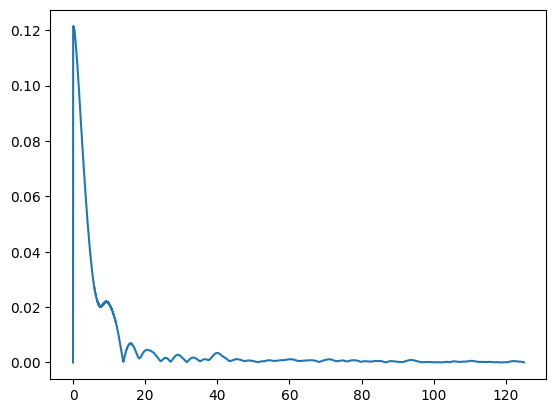

In [2]:
output_data = data_dict[f'{sample_freq}']['data']['output_data']
op = output_data[:, 0]
op -= op.mean()
N = output_data.shape[0]
# f = np.linspace(0, fps/2, nFreqs)
f = np.fft.rfftfreq(N, d=1.0/fps)
yf = np.fft.rfft(op)
A = np.abs(yf) / N
if N > 1:
    A[1:-1] *= 2
plt.plot(f, A)
plt.show()

Maximum frequency for 5 Hz is 15.987210231814545 Hz with a magnitude of 0.4164958940207194


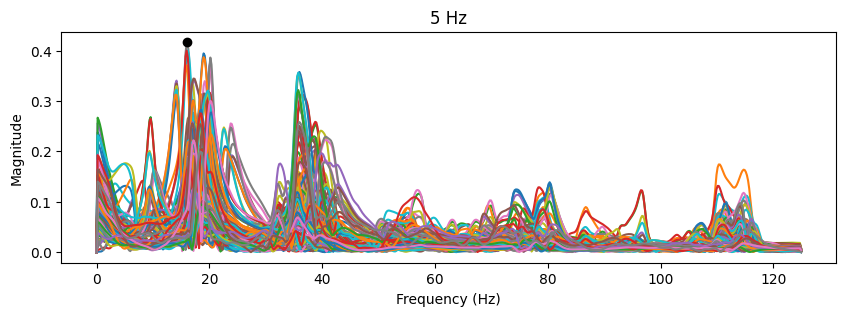

In [6]:
fig = plt.figure(figsize=(10, 3))
ax = plt.axes()
for j in range(len(sample_freq_list)):
    sample_freq = sample_freq_list[j]
    output_data = data_dict[f'{sample_freq}']['data']['output_data']

    N = output_data.shape[0]
    f = np.fft.rfftfreq(N, d=1.0/fps)

    fft_list = []

    max_A = 0

    for i in range(output_data.shape[1]):
        output_data = data_dict[f'{sample_freq}']['data']['output_data']
        op = output_data[:, i]
        op -= op.mean()
        yf = np.fft.rfft(op)
        A = np.abs(yf) / N
        if N > 1:
            A[1:-1] *= 2

        fft_list.append(A)
        current_max = np.max(A)

        if max_A <= current_max:
            max_A = current_max
            idx = np.where(A == current_max)[0][0]

        ax.plot(f, A)
    
    print(f"Maximum frequency for {sample_freq} Hz is {f[idx]} Hz with a magnitude of {max_A}")

    ax.scatter(f[idx], max_A, color='k', zorder=10)
    ax.set_ylabel('Magnitude')
    ax.set_title(f'{sample_freq} Hz')
    
    data_dict[f'{sample_freq}']['f'] = f
    data_dict[f'{sample_freq}']['ffts'] = fft_list

ax.set_xlabel('Frequency (Hz)')

plt.show()

### Force spacing grid

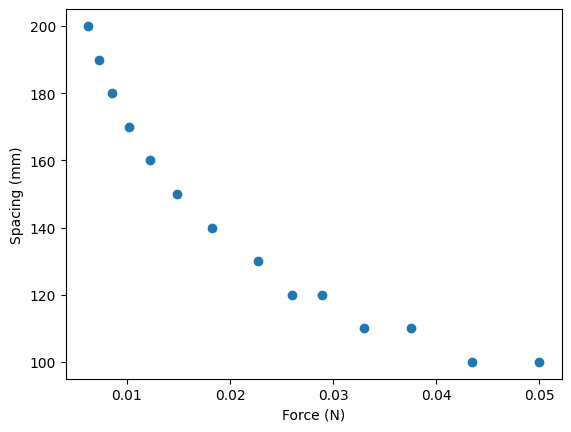

In [48]:
import numpy as np
import matplotlib.pyplot as plt

n = 6
radius = 300e-3
current_spacing = radius * np.cos(2 * np.pi / n)
spacing_list = [100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
product = 50e3

force_list = [product/s**3 for s in spacing_list]

# spacing_list_2 = spacing_list
# force_list_2 = force_list
# spacing_list_2.insert(1, 105)
# force_list_2.insert(1, 0.0435)

spacing_list.insert(1, spacing_list[0])
force_list.insert(1, 0.0435)

spacing_list.insert(3, spacing_list[2])
force_list.insert(3, 0.033)

spacing_list.insert(5, spacing_list[4])
force_list.insert(5, 0.026)

plt.figure()
plt.scatter(force_list, spacing_list, marker='o')
plt.xlabel("Force (N)")
plt.ylabel("Spacing (mm)")
plt.show()

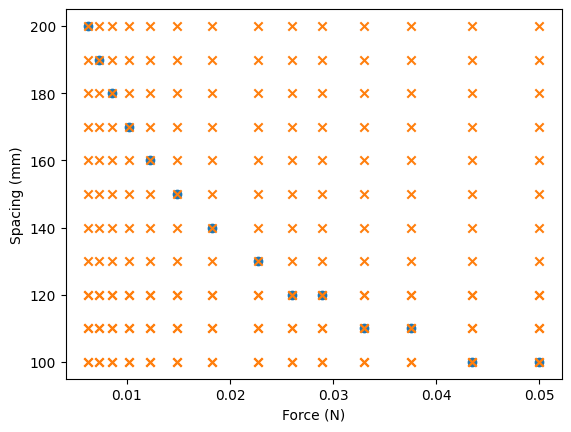

In [49]:
polygon_force_spacing_list = []
for s in spacing_list:
    for f in force_list:
        polygon_force_spacing_list.append((f, s))

polygon_force_spacing_grid = np.array(polygon_force_spacing_list)

plt.figure()
plt.scatter(force_list, spacing_list, marker='o')
plt.scatter(*zip(*polygon_force_spacing_list), marker='x')
plt.xlabel("Force (N)")
plt.ylabel("Spacing (mm)")
plt.show()

In [50]:
len(polygon_force_spacing_list)

196

In [52]:
polygon_force_spacing_grid

array([[5.00000000e-02, 1.00000000e+02],
       [4.35000000e-02, 1.00000000e+02],
       [3.75657400e-02, 1.00000000e+02],
       [3.30000000e-02, 1.00000000e+02],
       [2.89351852e-02, 1.00000000e+02],
       [2.60000000e-02, 1.00000000e+02],
       [2.27583068e-02, 1.00000000e+02],
       [1.82215743e-02, 1.00000000e+02],
       [1.48148148e-02, 1.00000000e+02],
       [1.22070312e-02, 1.00000000e+02],
       [1.01770812e-02, 1.00000000e+02],
       [8.57338820e-03, 1.00000000e+02],
       [7.28969237e-03, 1.00000000e+02],
       [6.25000000e-03, 1.00000000e+02],
       [5.00000000e-02, 1.00000000e+02],
       [4.35000000e-02, 1.00000000e+02],
       [3.75657400e-02, 1.00000000e+02],
       [3.30000000e-02, 1.00000000e+02],
       [2.89351852e-02, 1.00000000e+02],
       [2.60000000e-02, 1.00000000e+02],
       [2.27583068e-02, 1.00000000e+02],
       [1.82215743e-02, 1.00000000e+02],
       [1.48148148e-02, 1.00000000e+02],
       [1.22070312e-02, 1.00000000e+02],
       [1.017708

In [51]:
np.savez("SAGE_GridSearch_polygon_spacing/force_spacing_grid.npz", grid=polygon_force_spacing_grid)

### Frequency and size comparison

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fps = 250
point_force_mag = 1e-2
polygon_diameter = 600
dx = 10
sample_freq_list = [5, 10, 15]
TYPE_PF = 'spline'
num_sides_polygon_list = [6, 8, 10]


data_dict = {}
for num_sides_polygon in num_sides_polygon_list:
    for sample_freq in sample_freq_list:
        name = f"Polygon{num_sides_polygon}_PF{-point_force_mag:.0e}N{TYPE_PF}_{sample_freq}Hz_0" #_{n_file}"
        data = np.load(f"./{name}_eval.npz", allow_pickle=True)

        leg_test = data['legendre_R2'][1]
        mem_test = data['memory_R2'][1]

        data_dict[f'{num_sides_polygon}_{sample_freq}_leg'] = leg_test
        data_dict[f'{num_sides_polygon}_{sample_freq}_mem'] = mem_test

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(fps*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

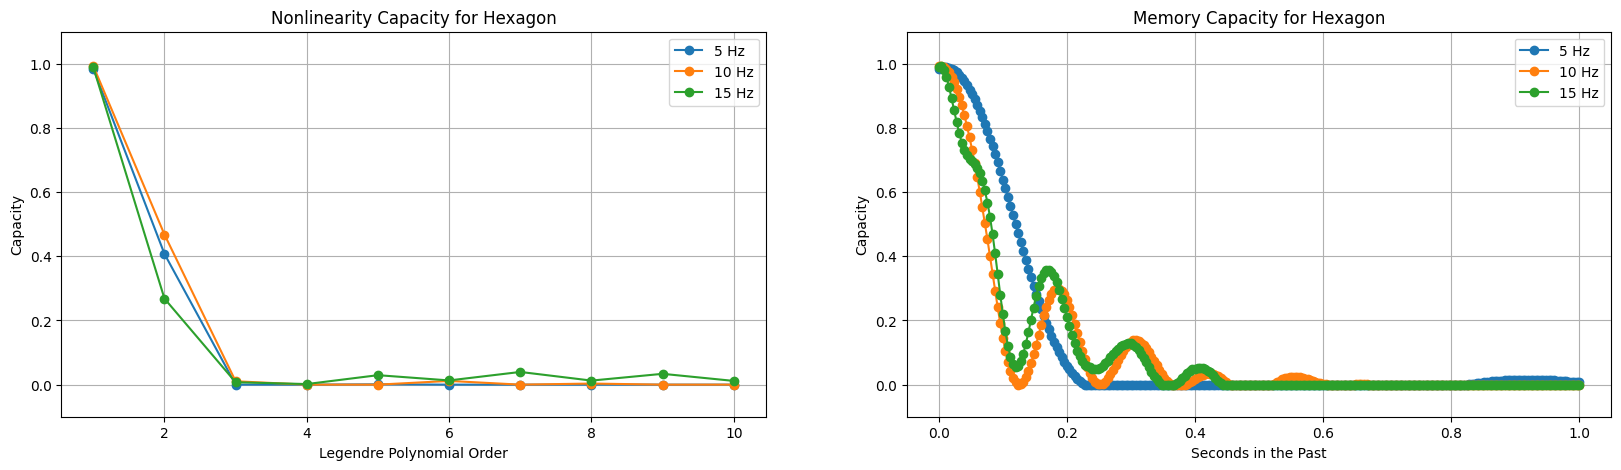

In [6]:
# Plotting Legendre and Memory for hexagon
num_sides_polygon = 6
plt.figure(figsize=(20, 5))
plt.subplot(121)
for sample_freq in sample_freq_list:
    leg_test = data_dict[f'{num_sides_polygon}_{sample_freq}_leg']
    plt.plot(leg_x, leg_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Capacity')
plt.title('Nonlinearity Capacity for Hexagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(122)
for sample_freq in sample_freq_list:
    mem_test = data_dict[f'{num_sides_polygon}_{sample_freq}_mem']
    plt.plot(mem_x, mem_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Seconds in the Past')
plt.ylabel('Capacity')
plt.title('Memory Capacity for Hexagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.show()

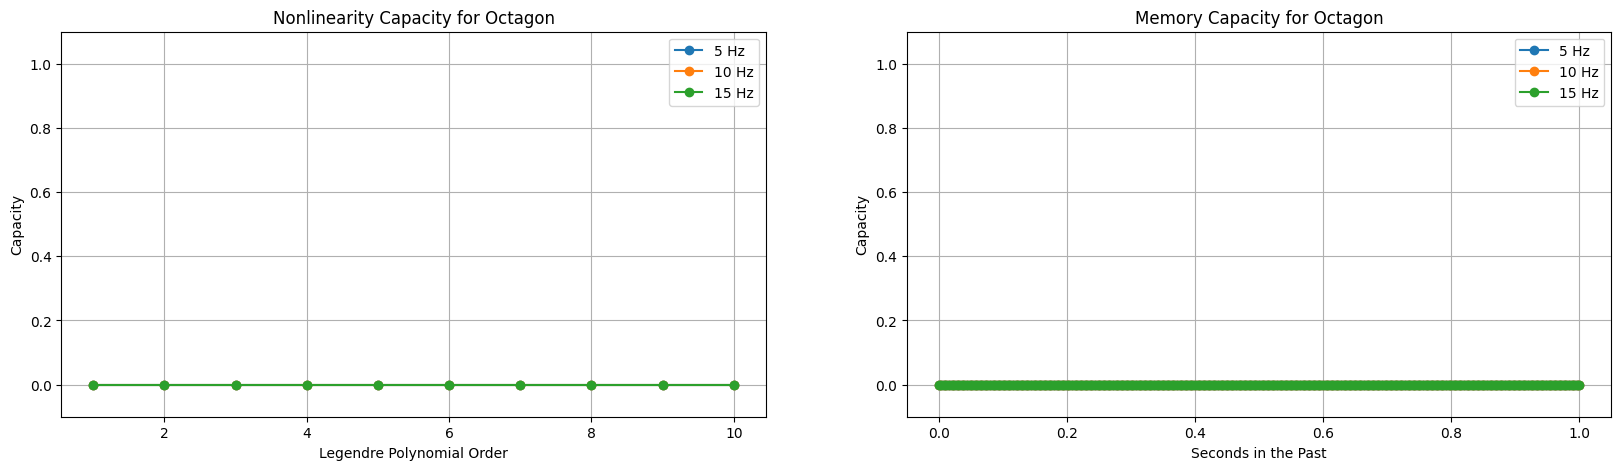

In [8]:
# Plotting Legendre and Memory for Octagon
num_sides_polygon = 8
plt.figure(figsize=(20, 5))
plt.subplot(121)
for sample_freq in sample_freq_list:
    leg_test = data_dict[f'{num_sides_polygon}_{sample_freq}_leg']
    plt.plot(leg_x, leg_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Capacity')
plt.title('Nonlinearity Capacity for Octagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(122)
for sample_freq in sample_freq_list:
    mem_test = data_dict[f'{num_sides_polygon}_{sample_freq}_mem']
    plt.plot(mem_x, mem_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Seconds in the Past')
plt.ylabel('Capacity')
plt.title('Memory Capacity for Octagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.show()

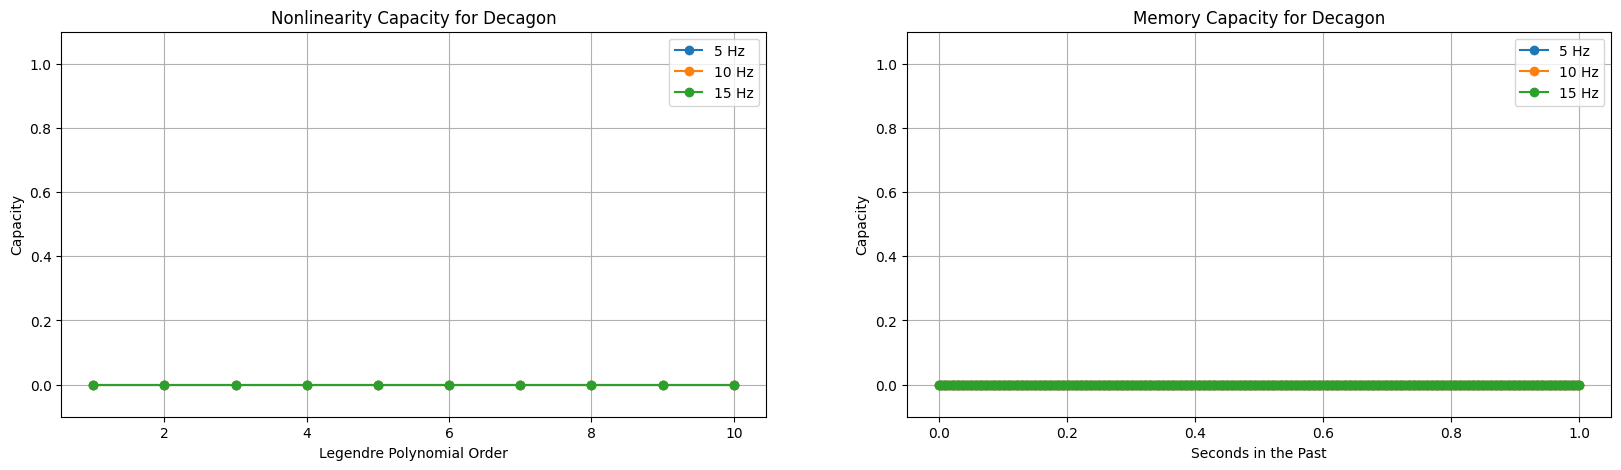

In [9]:
# Plotting Legendre and Memory for Decagon
num_sides_polygon = 10
plt.figure(figsize=(20, 5))
plt.subplot(121)
for sample_freq in sample_freq_list:
    leg_test = data_dict[f'{num_sides_polygon}_{sample_freq}_leg']
    plt.plot(leg_x, leg_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Capacity')
plt.title('Nonlinearity Capacity for Decagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(122)
for sample_freq in sample_freq_list:
    mem_test = data_dict[f'{num_sides_polygon}_{sample_freq}_mem']
    plt.plot(mem_x, mem_test, '-o', label=f'{sample_freq} Hz')
plt.xlabel('Seconds in the Past')
plt.ylabel('Capacity')
plt.title('Memory Capacity for Decagon')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.show()